> 📅 __Date: 2026-07-20__

# __ANN Implementation__

# 📚 __1. Import Required Libraries__

Before building an Artificial Neural Network (ANN), we first install (if required) and then import the necessary libraries.

### __Install Required Libraries__

```python
!pip install pandas numpy scikit-learn tensorflow
```

> **Note:** Google Colab already has these libraries pre-installed, so this step is usually not required.

### __Libraries Used__

- **Pandas** → Load and manipulate the dataset.
- **NumPy** → Numerical computations (used internally).
- **TensorFlow/Keras** → Build and train the ANN.
- **Scikit-learn** → Data preprocessing and train-test split.

---

In [1]:
import pandas as pd

# 📂 __2. Load Dataset__

We are using the **California Housing Dataset** provided by Google Colab.

### __Objective__

Predict the **Median House Value** using different housing-related features.

### __Features__

- longitude
- latitude
- housing_median_age
- total_rooms
- total_bedrooms
- population
- households
- median_income

### __Target__

- median_house_value

---

In [2]:
# Read the dataset into a Pandas DataFrame
df = pd.read_csv("/content/sample_data/california_housing_train.csv")

# Preview the first 5 records to understand the dataset structure
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


# 🔍 __3. Explore the Dataset__

Before training any Machine Learning or Deep Learning model, it is important to understand the dataset.

We generally check:

- Number of rows and columns
- Missing values
- Data types
- Basic statistics

This helps us identify whether preprocessing is required.

---

In [3]:
# Display the number of rows and columns in the dataset
df.shape

(17000, 9)

In [4]:
# Check the number of missing (NaN) values in each column
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


# 🎯 __4. Separate Features and Target__

Machine Learning models learn from **Features (X)** to predict the **Target (y).**

### __Features (X)__

All input columns except the target.

### __Target (y)__

The value that the ANN will predict.

Here,

- **X → Housing Information**
- **y → Median House Value**

---

In [5]:
# Create the Feature matrix (X) by dropping the target column
X = df.drop(columns=["median_house_value"])

# Create the Target vector (y) containing the house prices to be predicted
y = df["median_house_value"]

# ✂️ __5. Split Dataset into Training & Testing__

We divide the dataset into two parts.

## __Training Data__

Used to train the ANN.

## __Testing Data__

Used to evaluate the performance of the trained model.

### __Why Split the Data?__

If we train and test on the same data, the model may simply memorize the dataset instead of learning meaningful patterns.

Common split:

- Training → 80%
- Testing → 20%

`random_state` ensures that the split remains the same every time the notebook is executed.

---

In [6]:
# Import the function to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

# ⚖️ __6. Feature Scaling__

ANNs train faster when all input features are on a similar scale.

Different features in this dataset have very different ranges.

**Example**

- Population → Thousands
- Median Income → Single digits

Without scaling, features with larger values dominate the learning process.

We use **StandardScaler**, which transforms every feature into a distribution with

- Mean = 0
- Standard Deviation = 1

### __Why fit only on Training Data?__

The scaler learns statistics (mean & standard deviation) only from the training data.

The same transformation is then applied to the test data.

This prevents **Data Leakage**.

---

In [7]:
# Import StandardScaler to standardize the feature values
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler
scaler = StandardScaler()

# Learn the scaling parameters from the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling parameters to the testing data
X_test_scaled = scaler.transform(X_test)

# 🧠 __7. Steps to Build an Artificial Neural Network__

Building an ANN in TensorFlow follows four simple steps.

## __Step 1__

**Define the Model**

A Sequential model stacks layers one after another.

---

## __Step 2__

**Add Layers**

- Input Layer
- Hidden Layer(s)
- Output Layer

---

## __Step 3__

**Compile the Model**

Specify

- Optimizer
- Loss Function
- Metrics (Optional)

---

## __Step 4__

**Train the Model**

Train the ANN using the training dataset.

---

## __Step 5__

**Evaluate the Model**

Measure the model's performance on unseen test data.

---

# 🤖 __8. Import TensorFlow Libraries__

Before importing TensorFlow, install it (if it is not already installed).

```python
!pip install tensorflow
```

> **Note:** Google Colab already comes with TensorFlow pre-installed, so this step is usually not required. It is mainly needed when working in a local Jupyter Notebook or a new Python environment.

---

## __Why TensorFlow?__

TensorFlow is one of the most popular Deep Learning frameworks developed by Google. It provides high-level APIs for building, training, and deploying Artificial Neural Networks (ANNs).

We use:

- **Sequential** → Creates a linear stack of layers.
- **Dense** → Creates a Fully Connected (Dense) Layer where every neuron is connected to every neuron in the previous layer.

---

In [8]:
# Import Sequential to create a linear stack of neural network layers
from tensorflow.keras import Sequential

# Import Dense to create Fully Connected (Dense) layers
from tensorflow.keras.layers import Dense

# 🏗️ __9. Define the ANN__

We first create an empty Sequential model.

Later, layers will be added one by one.

---

In [9]:
# Create an empty Sequential model
model = Sequential()

# ➕ __10. Add Layers to the ANN__

Our ANN contains

## __Input Layer__

Receives the 8 input features.

---

## __Hidden Layer 1__

- 10 Neurons
- ReLU Activation

---

## __Hidden Layer 2__

- 20 Neurons
- ReLU Activation

---

## __Output Layer__

- 1 Neuron
- Linear Activation

Since this is a **Regression Problem**, the output layer uses **Linear Activation**.

---

In [10]:
# Add the input layer and first hidden layer with 10 neurons using ReLU activation
model.add(Dense(units=10, activation="relu", input_dim=8))

# Add the second hidden layer with 20 neurons using ReLU activation
model.add(Dense(units=20, activation="relu"))

# Add the output layer with 1 neuron using Linear activation (for Regression)
model.add(Dense(units=1, activation="linear"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# ⚙️ __11. Compile the ANN__

Before training, we must configure the model.

## __Optimizer__

**Adam**

- Adaptive Learning Rate
- Fast convergence
- Most commonly used optimizer

---

## __Loss Function__

Mean Squared Error (MSE)

Since house price prediction is a **Regression Problem**, MSE is an appropriate loss function.

The model tries to minimize this loss during training.

---

In [11]:
# Compile the model by specifying the optimizer and loss function
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Display the architecture and trainable parameters of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331 (1.29 KB)

 Trainable params: 331 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

# 🔢 __12. Number of Trainable Parameters__

Each Dense layer contains

## __Weights__

Every neuron in the previous layer connects to every neuron in the current layer.

Formula

Weights = Previous Layer Neurons × Current Layer Neurons

---

## __Biases__

Every neuron has one bias.

Formula

Biases = Number of Current Layer Neurons

---

## __Total Parameters__

Total Parameters = Weights + Biases

### __Example__

Input Layer → Hidden Layer

Previous Layer = 8 neurons

Current Layer = 10 neurons

Weights = 8 × 10 = 80

Biases = 10

Total = 90 Parameters

---

# 🚀 __13. Train the ANN__

Training means updating the weights and biases using **Backpropagation** and **Gradient Descent**.

### __Epoch__

One complete pass through the entire training dataset.

Here,

Epochs = 10

The model will see the entire dataset **10 times**.

---

### __Batch Size__

Instead of processing the entire dataset at once, it is divided into smaller batches.

Batch Size = 32

The model updates weights after processing every 32 samples.

---

### __Number of Iterations__

Iterations = Total Samples ÷ Batch Size

Example

13600 samples

Batch Size = 32

Iterations ≈ 425 per Epoch

---

In [12]:
# Train the ANN on the training data and store the training history
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32
)

Epoch 1/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 56490360832.0000
Epoch 2/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 56313163776.0000
Epoch 3/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 55630184448.0000
Epoch 4/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54255677440.0000
Epoch 5/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 52131344384.0000
Epoch 6/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49282367488.0000
Epoch 7/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45796110336.0000
Epoch 8/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 41813790720.0000
Epoch 9/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 37531697152.0000
Epoch 10/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 33158217728.0000
Epoch 11/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 28917460992.0000
Epoch 12/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25028349952.0000
Epoch 13/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss:

# 🔄 __14. Number of Iterations__

One Epoch contains multiple iterations.

Formula

Iterations = Number of Training Samples / Batch Size

---

In [13]:
# Calculate the number of iterations (batches) per epoch
len(X_train_scaled) / 32

425.0

# 📊 __15. Evaluate the Model__

After training, we evaluate the ANN on the testing dataset.

The testing data was **not used during training**, so it provides an unbiased estimate of the model's performance.

Since this is a Regression problem, we use **Mean Squared Error (MSE)** as the loss function.

A lower MSE indicates better predictions.

In [14]:
# Evaluate the trained model on the testing data
test_loss = model.evaluate(X_test_scaled, y_test)

print("Test Loss (MSE):", test_loss)

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4541282816.0000
Test Loss (MSE): 4541282816.0


In [15]:
# Predict house prices for the testing data
y_pred = model.predict(X_test_scaled)

# Display the first 5 predictions
y_pred[:5]

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[185897.89],
       [270795.5 ],
       [104681.94],
       [156068.92],
       [318124.06]], dtype=float32)

In [16]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})

comparison.head(10)

,Actual,Predicted
0,97300.0,185897.890625
1,270800.0,270795.500000
2,89000.0,104681.937500
3,124600.0,156068.921875
4,386500.0,318124.062500
5,500001.0,279110.718750
6,500001.0,557390.937500
7,147800.0,87124.156250
8,241200.0,269889.781250
9,195800.0,243253.671875


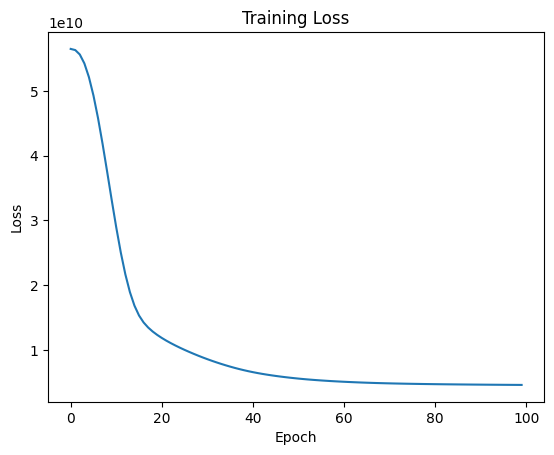

In [17]:
import matplotlib.pyplot as plt

# Plot the training loss over epochs
plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"MAE      : {mean_absolute_error(y_test, y_pred):,.2f}")
print(f"MSE      : {mean_squared_error(y_test, y_pred):,.2f}")
print(f"RMSE     : {mean_squared_error(y_test, y_pred) ** 0.5:,.2f}")
print(f"R² Score : {r2_score(y_test, y_pred):.4f}")

MAE      : 49,005.90
MSE      : 4,541,282,081.12
RMSE     : 67,389.04
R² Score : 0.6691
